# Mac local — wipe ESN (task loss @ 10 ms + VLA anchor @ 570 ms)

Kernel: **`.venv (Mac notebooks)`** → `research/notebooks/.venv`.
Workstation notebooks stay on **Research Summer 2026 (UnifoLM)**.

## What this is (and is not)

| Clock | Period | Role |
|---|---|---|
| Unitree demo / teleop | **33.3 ms** (30 Hz) | **Real** recorded frames |
| ESN / G1 control | **10 ms** (100 Hz) | Reservoir **step** rate |
| UnifoLM-style teacher | **~570 ms** | Slow **anchor**, not an interpolator |

**Plumbing only:** linear interpolation puts demo joints on a 10 ms grid so the ESN can tick at 100 Hz. That interpolant **is** curve fitting and is **not** the learning target.

**One training loop, two terms:**

- At **every 10 ms**: `L_task` (wipe: action, arm/EE proxy, grasp/contact/wipe phase weights, smoothness).
- At **every ~570 ms only**: also `L_VLA` = MSE to the slow teacher. Both terms apply on those ticks.

`L = L_task(t) + lambda * L_VLA(T)` where `T` is 0, 570, 1140, ... ms.

Live UnifoLM is **not** run. `q_slow` is a **zero-order hold** of demo `observation.body` (29-D), standing in for a slow VLA joint command.

Input **58-D** = present 29-D + slow 29-D. Output **29-D** fast body. Reservoir N is a **multiple of 58**.


In [10]:
! pip3 install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 31.2 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 32.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 28.0 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [3]:
from datasets import load_dataset

ds = load_dataset("unitreerobotics/G1_Dex1_Wipe_Table")
ds


/Users/andrew/Library/Mobile Documents/com~apple~CloudDocs/Desktop/devops-sre/myjarvis/robotics/research/notebooks/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['observation.left_arm', 'observation.right_arm', 'observation.left_gripper', 'observation.right_gripper', 'observation.left_ee', 'observation.right_ee', 'observation.body', 'action.left_arm', 'action.right_arm', 'action.left_gripper', 'action.right_gripper', 'action.left_ee', 'action.right_ee', 'action.body', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
        num_rows: 75909
    })
})

## 1. Clocks and smoke vs full sweep

`SMOKE = True` (default): 4 train episodes, 2 held-out, `N in {58, 580}` so a Mac run finishes.
Set `SMOKE = False` for 0-159 / 160-199 and larger N (58000+ is a workstation job, not 5.8e7).


In [ ]:
from collections import defaultdict
from dataclasses import dataclass, field

import numpy as np
from numpy.linalg import solve

# --- clocks (seconds) ---
DT_DEMO = 1.0 / 30.0  # 33.3 ms recorded teleop
DT_ESN = 0.010        # 10 ms ESN / control step
HOLD_S = 0.570        # 570 ms UnifoLM-on-V100 class teacher
HOLD_STEPS = max(1, int(round(HOLD_S / DT_ESN)))  # 57 ticks between anchors

G1_DOF = 29
IN_DIM = 58  # [q_present (29); q_slow (29)]
ARM_SLICE = slice(15, 29)  # body[15:22] left arm, [22:29] right arm

# L = L_task + LAMBDA_VLA * L_VLA  (second term only on anchor ticks)
LAM_ACTION = 1.0
LAM_EE = 1.0
LAM_GRASP = 0.5
LAM_CONTACT = 0.5
LAM_WIPE = 0.5
LAM_SMOOTH = 1e-3
LAMBDA_VLA = 1.0
RIDGE = 1.0

RHO = 0.95       # spectral radius of reservoir W
LEAK = 0.3       # leaky integrator
SPARSITY = 0.90  # fraction of W entries set to 0
WASH = 50        # drop first ticks (reservoir transient)

SMOKE = False
if SMOKE:
    TRAIN_EPS = list(range(0, 4))
    HELDOUT_EPS = list(range(160, 162))
    N_GRID = [58, 580]  # 1x and 10x input dim
else:
    TRAIN_EPS = list(range(0, 160))
    HELDOUT_EPS = list(range(160, 200))
    N_GRID = [580, 5800]
    # N_GRID = [580, 5800, 58000,580000,5800000,58000000]

print(f"HOLD_STEPS={HOLD_STEPS}  (VLA MSE every {HOLD_STEPS * DT_ESN * 1000:.0f} ms)")
print(f"SMOKE={SMOKE}  train={TRAIN_EPS[0]}..{TRAIN_EPS[-1]}  heldout={HELDOUT_EPS[0]}..{HELDOUT_EPS[-1]}")
print(f"N_GRID={N_GRID}")


HOLD_STEPS=57  (VLA MSE every 570 ms)
SMOKE=False  train=0..159  heldout=160..199
N_GRID=[580, 5800, 58000]


## 2. Pack episodes from Hugging Face

`observation.body` is the 29-D G1 joint vector (present state **and** held slow intent).
Grippers / EE are **not** in that 29-D; they only build **phase masks** for `L_task` (no MuJoCo FK here).


In [4]:
split = ds["train"]


def _vec(row, key, n):
    x = np.asarray(row[key], dtype=np.float32).reshape(-1)
    if x.size != n:
        raise ValueError(f"{key}: expected {n} got {x.size}")
    return x


needed = set(TRAIN_EPS) | set(HELDOUT_EPS)
by_ep = defaultdict(list)
for row in split:
    ep = int(row["episode_index"])
    if ep not in needed:
        continue
    by_ep[ep].append(row)

raw = {}
for ep, rows in sorted(by_ep.items()):
    rows.sort(key=lambda r: int(r["frame_index"]))
    raw[ep] = {
        "t": np.array([float(r["timestamp"]) for r in rows], dtype=np.float64),
        "q": np.stack([_vec(r, "observation.body", G1_DOF) for r in rows]),
        "grip_l": np.array([float(r["observation.left_gripper"]) for r in rows], dtype=np.float32),
        "grip_r": np.array([float(r["observation.right_gripper"]) for r in rows], dtype=np.float32),
        "ee_l": np.stack([_vec(r, "observation.left_ee", 6) for r in rows]),
        "ee_r": np.stack([_vec(r, "observation.right_ee", 6) for r in rows]),
    }
    print(f"ep {ep:3d}  frames={len(rows):4d}  dur={raw[ep]['t'][-1] - raw[ep]['t'][0]:.2f}s")

print("packed", sorted(raw))


ep   0  frames= 370  dur=12.30s
ep   1  frames= 459  dur=15.27s
ep   2  frames= 401  dur=13.33s
ep   3  frames= 413  dur=13.73s
ep   4  frames= 462  dur=15.37s
ep   5  frames= 445  dur=14.80s
ep   6  frames= 305  dur=10.13s
ep   7  frames= 426  dur=14.17s
ep   8  frames= 399  dur=13.27s
ep   9  frames= 316  dur=10.50s
ep  10  frames= 401  dur=13.33s
ep  11  frames= 373  dur=12.40s
ep  12  frames= 335  dur=11.13s
ep  13  frames= 381  dur=12.67s
ep  14  frames= 362  dur=12.03s
ep  15  frames= 300  dur=9.97s
ep  16  frames= 399  dur=13.27s
ep  17  frames= 341  dur=11.33s
ep  18  frames= 377  dur=12.53s
ep  19  frames= 458  dur=15.23s
ep  20  frames= 445  dur=14.80s
ep  21  frames= 412  dur=13.70s
ep  22  frames= 366  dur=12.17s
ep  23  frames= 389  dur=12.93s
ep  24  frames= 346  dur=11.50s
ep  25  frames= 453  dur=15.07s
ep  26  frames= 368  dur=12.23s
ep  27  frames= 318  dur=10.57s
ep  28  frames= 382  dur=12.70s
ep  29  frames= 311  dur=10.33s
ep  30  frames= 335  dur=11.13s
ep  31  f

## 3. Resample 33.3 ms → 10 ms (clock only)

`np.interp` is piecewise-linear curve fitting. Use it **only** so arrays exist at 10 ms.
Do **not** treat `q` as better ground truth than the 30 Hz samples.

`q_slow` = zero-order hold of `q` for `HOLD_STEPS` ticks ≈ 570 ms (stand-in VLA command).


In [5]:
def upsample_cols(t, y, t2):
    """Linear interp of (T,) or (T, D) onto t2. Plumbing, not a learned upsampler."""
    y = np.asarray(y, dtype=np.float64)
    if y.ndim == 1:
        y = y[:, None]
    out = np.empty((t2.size, y.shape[1]), dtype=np.float32)
    for j in range(y.shape[1]):
        out[:, j] = np.interp(t2, t, y[:, j])
    return out


def zoh_hold(q, hold_steps):
    """Latch q[i] for hold_steps rows — slow teacher between VLA updates."""
    slow = np.empty_like(q)
    for i in range(0, len(q), hold_steps):
        slow[i : i + hold_steps] = q[i]
    return slow


def resample_episode(ep):
    t = raw[ep]["t"]
    t2 = np.arange(t[0], t[-1] + 1e-9, DT_ESN)
    q = upsample_cols(t, raw[ep]["q"], t2)
    grip = upsample_cols(t, np.stack([raw[ep]["grip_l"], raw[ep]["grip_r"]], axis=1), t2)
    ee_l = upsample_cols(t, raw[ep]["ee_l"], t2)
    ee_r = upsample_cols(t, raw[ep]["ee_r"], t2)
    # Wipe hand = EE with larger xy travel this episode.
    span_l = np.ptp(ee_l[:, :2], axis=0).sum()
    span_r = np.ptp(ee_r[:, :2], axis=0).sum()
    use_l = span_l >= span_r
    ee = ee_l if use_l else ee_r
    g = grip[:, 0] if use_l else grip[:, 1]
    return {
        "t": t2.astype(np.float32),
        "q": q,
        "q_slow": zoh_hold(q, HOLD_STEPS),
        "ee": ee,
        "grip": g.astype(np.float32),
        "vla_mask": (np.arange(len(q)) % HOLD_STEPS == 0),
    }


fast = {ep: resample_episode(ep) for ep in raw}
ep0 = TRAIN_EPS[0]
print(
    f"ep {ep0}: demo frames={len(raw[ep0]['t'])} -> 10ms ticks={len(fast[ep0]['t'])} "
    f"VLA anchors={int(fast[ep0]['vla_mask'].sum())}"
)


ep 0: demo frames=370 -> 10ms ticks=1231 VLA anchors=22


## 4. Wipe phase masks (from **demo** EE / gripper)

Without FK we cannot map predicted 29-D joints to xyz. Grasp / contact / wipe therefore **reweight** joint error on frames the **demo** says are those phases.

That is still `L_task` at 10 ms — not MSE to the interpolant as the paper.


In [6]:
def phase_masks(ep_d):
    g = ep_d["grip"]
    z = ep_d["ee"][:, 2]
    xy = ep_d["ee"][:, :2]
    vxy = np.zeros(len(g), dtype=np.float32)
    vxy[1:] = np.linalg.norm(np.diff(xy, axis=0), axis=1) / DT_ESN
    g_thr = np.quantile(g, 0.40)
    grasp = g <= g_thr
    z_table = float(np.median(z[grasp])) if grasp.any() else float(np.median(z))
    contact = grasp & (np.abs(z - z_table) < 0.04)
    wipe = contact & (vxy > 0.05)
    return grasp, contact, wipe


def sample_weight(grasp, contact, wipe):
    """Per-tick multiplier on joint tracking (L_action + phase terms)."""
    w = np.full(grasp.shape[0], LAM_ACTION, dtype=np.float64)
    w += LAM_GRASP * grasp.astype(np.float64)
    w += LAM_CONTACT * contact.astype(np.float64)
    w += LAM_WIPE * wipe.astype(np.float64)
    return w


g0, c0, w0 = phase_masks(fast[ep0])
print(f"ep {ep0} fractions  grasp={g0.mean():.2f}  contact={c0.mean():.2f}  wipe={w0.mean():.2f}")


ep 0 fractions  grasp=0.40  contact=0.36  wipe=0.35


## 5. Leaky ESN (fixed W and Win; train readout only)

`h_t = (1-a)*h_{t-1} + a*tanh(Win @ u_t + W @ h_{t-1})`
`qhat_t = Wout @ [h_t; u_t]`

`u_t` is 58-D. `N` must be a multiple of 58.


In [7]:
@dataclass
class ESN:
    n: int
    leak: float = LEAK
    rng: np.random.Generator = field(default_factory=lambda: np.random.default_rng(0))

    def __post_init__(self):
        if self.n % IN_DIM != 0:
            raise ValueError(f"N={self.n} must be a multiple of {IN_DIM}")
        rng = self.rng
        self.Win = rng.uniform(-0.1, 0.1, (self.n, IN_DIM)).astype(np.float32)
        w = rng.uniform(-1.0, 1.0, (self.n, self.n)).astype(np.float32)
        w[rng.random((self.n, self.n)) < SPARSITY] = 0.0
        probe = min(self.n, 2048)
        if probe < self.n:
            idx = rng.choice(self.n, probe, replace=False)
            eig = np.max(np.abs(np.linalg.eigvals(w[np.ix_(idx, idx)].astype(np.float64))))
            eig *= self.n / probe
        else:
            eig = np.max(np.abs(np.linalg.eigvals(w.astype(np.float64))))
        self.W = (w * (RHO / (eig + 1e-8))).astype(np.float32)
        self.Wout = np.zeros((G1_DOF, self.n + IN_DIM), dtype=np.float32)
        self.h = np.zeros(self.n, dtype=np.float32)

    def reset(self):
        self.h[:] = 0.0

    def step(self, u):
        u = np.asarray(u, dtype=np.float32)
        self.h = (1.0 - self.leak) * self.h + self.leak * np.tanh(
            self.Win @ u + self.W @ self.h
        )
        return self.h

    def predict(self, u):
        phi = np.concatenate([self.step(u), np.asarray(u, dtype=np.float32)])
        return self.Wout @ phi


## 6. Combined loss as weighted least squares on Wout

Closed-form ridge (same idea as the CUDA ESN readout):

1. **Every tick:** track demo body; weight `w_t` from phase masks; extra `LAM_EE` on arm joints.
2. **Every 57 ticks:** extra `qhat ≈ q_slow` (`LAMBDA_VLA`) — the VLA anchor.
3. **Every tick:** smoothness via `LAM_SMOOTH` on `phi_t - phi_{t-1}`.

Interpolation only **built** `q`. The VLA term is **sparse**; phases + smoothness shape the in-between ticks.


In [8]:
def rollout_design(esn, ep):
    """Phi rows, demo q, slow q, weights, VLA mask (after washout)."""
    d = fast[ep]
    q, slow = d["q"], d["q_slow"]
    grasp, contact, wipe = phase_masks(d)
    w = sample_weight(grasp, contact, wipe)
    esn.reset()
    phis, ys, sls, ws, ms = [], [], [], [], []
    for t in range(len(q) - 1):
        u = np.concatenate([q[t], slow[t]])
        h = esn.step(u)
        if t < WASH:
            continue
        phis.append(np.concatenate([h, u]))
        ys.append(q[t + 1])
        sls.append(slow[t + 1])
        ws.append(w[t + 1])
        ms.append(d["vla_mask"][t + 1])
    return (
        np.stack(phis),
        np.stack(ys),
        np.stack(sls),
        np.asarray(ws),
        np.asarray(ms, dtype=bool),
    )


def fit_readout(esn, episodes):
    """Per-joint WLS so extra arm weight cannot pull legs to zero."""
    Phis, Ys, Yslows, ws, ms, dPhis = [], [], [], [], [], []
    for ep in episodes:
        Phi, Y, Yslow, w, m = rollout_design(esn, ep)
        Phis.append(Phi)
        Ys.append(Y)
        Yslows.append(Yslow)
        ws.append(w)
        ms.append(m)
        dPhis.append(np.diff(Phi, axis=0))
    Phi = np.vstack(Phis)
    Y = np.vstack(Ys)
    Yslow = np.vstack(Yslows)
    w = np.concatenate(ws)
    m = np.concatenate(ms)
    dPhi = np.vstack(dPhis)
    d = Phi.shape[1]
    Wout = np.zeros((G1_DOF, d), dtype=np.float64)
    I = np.eye(d)
    sm = np.sqrt(LAM_SMOOTH)
    lam_v = np.sqrt(LAMBDA_VLA)
    for j in range(G1_DOF):
        extra = 1.0 + LAM_EE if j >= ARM_SLICE.start else 1.0
        wt = np.sqrt(np.maximum(w * extra, 1e-12))
        P = Phi * wt[:, None]
        y = Y[:, j] * wt
        if m.any():
            P = np.vstack([P, Phi[m] * lam_v])
            y = np.concatenate([y, Yslow[m, j] * lam_v])
        P = np.vstack([P, dPhi * sm])
        y = np.concatenate([y, np.zeros(len(dPhi))])
        Wout[j] = solve(P.T @ P + RIDGE * I, P.T @ y)
    esn.Wout = Wout.astype(np.float32)
    return esn


def eval_losses(esn, episodes):
    """L_task pieces + L_VLA on anchors only (no re-fit)."""
    acc = {k: [] for k in ("action", "ee", "smooth", "vla")}
    for ep in episodes:
        d = fast[ep]
        q, slow = d["q"], d["q_slow"]
        esn.reset()
        prev = None
        for t in range(len(q) - 1):
            u = np.concatenate([q[t], slow[t]])
            qhat = esn.predict(u)
            tgt = q[t + 1]
            acc["action"].append(float(np.mean((qhat - tgt) ** 2)))
            acc["ee"].append(float(np.mean((qhat[ARM_SLICE] - tgt[ARM_SLICE]) ** 2)))
            if prev is not None:
                acc["smooth"].append(float(np.mean((qhat - prev) ** 2)))
            prev = qhat
            if d["vla_mask"][t + 1]:
                acc["vla"].append(float(np.mean((qhat - slow[t + 1]) ** 2)))
    out = {
        "L_action": float(np.mean(acc["action"])),
        "L_ee": float(np.mean(acc["ee"])),
        "L_smooth": float(np.mean(acc["smooth"])) if acc["smooth"] else 0.0,
        "L_VLA": float(np.mean(acc["vla"])) if acc["vla"] else float("nan"),
        "n_VLA_anchors": int(len(acc["vla"])),
    }
    out["L_task"] = (
        LAM_ACTION * out["L_action"]
        + LAM_EE * out["L_ee"]
        + LAM_SMOOTH * out["L_smooth"]
    )
    vla = out["L_VLA"] if np.isfinite(out["L_VLA"]) else 0.0
    out["L"] = out["L_task"] + LAMBDA_VLA * vla
    return out


## 7. Sweep N = 58 * 10^k and fit readout


In [ ]:
rows = []
fitted = {}
for N in N_GRID:
    esn = ESN(n=N, rng=np.random.default_rng(0))
    print(f"\n=== N={N} ({N // IN_DIM} x {IN_DIM})  fit on {len(TRAIN_EPS)} eps ===")
    fit_readout(esn, TRAIN_EPS)
    tr = eval_losses(esn, TRAIN_EPS)
    ho = eval_losses(esn, HELDOUT_EPS)
    rec = {"N": N, **{f"train_{k}": v for k, v in tr.items()}, **{f"heldout_{k}": v for k, v in ho.items()}}
    rows.append(rec)
    fitted[N] = esn
    show = ("L", "L_task", "L_VLA", "L_action")
    print("train ", {k: round(tr[k], 6) if isinstance(tr[k], float) else tr[k] for k in show})
    print("heldout", {k: round(ho[k], 6) if isinstance(ho[k], float) else ho[k] for k in show})

print("\n=== summary ===")
keys = ["N", "train_L_action", "heldout_L_action", "train_L_VLA", "heldout_L_VLA", "heldout_L"]
print(keys)
for rec in rows:
    print([rec[k] if k == "N" else round(float(rec[k]), 6) for k in keys])



=== N=580 (10 x 58)  fit on 160 eps ===
train  {'L': 3.1e-05, 'L_task': 3e-05, 'L_VLA': 1e-06, 'L_action': 1.3e-05}
heldout {'L': 3e-05, 'L_task': 2.9e-05, 'L_VLA': 1e-06, 'L_action': 1.3e-05}

=== N=5800 (100 x 58)  fit on 160 eps ===
train  {'L': 8.8e-05, 'L_task': 8.8e-05, 'L_VLA': 0.0, 'L_action': 3.9e-05}
heldout {'L': 8.7e-05, 'L_task': 8.7e-05, 'L_VLA': 1e-06, 'L_action': 3.9e-05}

=== N=58000 (1000 x 58)  fit on 160 eps ===


## 8. Sanity plot — held-out joint (one episode)

Green dots = VLA / hold **anchors** (every 570 ms). The ESN should track the demo at 10 ms and stay close to those dots when they appear — without being trained only to copy the interpolant.


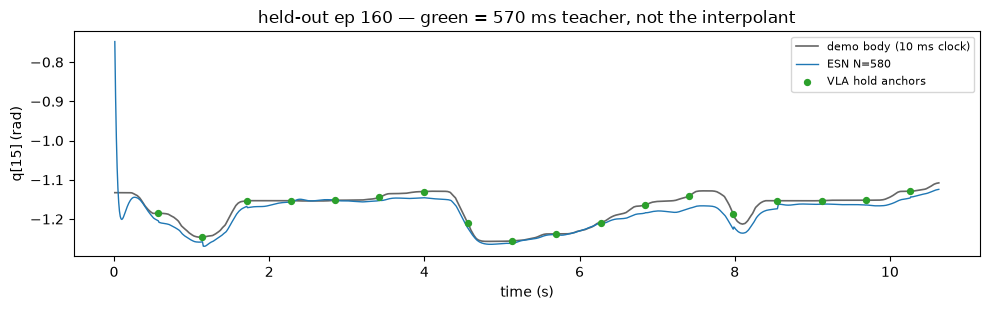

In [ ]:
import matplotlib.pyplot as plt

N_show = N_GRID[-1]
esn = fitted[N_show]
ep = HELDOUT_EPS[0]
d = fast[ep]
q, slow = d["q"], d["q_slow"]
esn.reset()
qhat = []
for t in range(len(q) - 1):
    u = np.concatenate([q[t], slow[t]])
    qhat.append(esn.predict(u))
qhat = np.stack(qhat)
tt = d["t"][1:]
m = d["vla_mask"][1:]

j = 15  # first left-arm joint in observation.body
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(tt, q[1:, j], color="0.4", lw=1.2, label="demo body (10 ms clock)")
ax.plot(tt, qhat[:, j], color="C0", lw=1.0, label=f"ESN N={N_show}")
ax.scatter(tt[m], slow[1:][m, j], s=18, c="C2", zorder=3, label="VLA hold anchors")
ax.set_xlabel("time (s)")
ax.set_ylabel(f"q[{j}] (rad)")
ax.set_title(f"held-out ep {ep} — green = 570 ms teacher, not the interpolant")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()


## Next (not in this Mac smoke)

1. `SMOKE = False` where N=5800 or 58000 fits RAM.
2. Replace `q_slow` ZOH with **real UnifoLM** 29-D (or IK-mapped EE) at 570 ms on the lab GPU.
3. Advisor Step 1: if you obtain **true** 100 Hz expert u(t), train **MSE-only** to that trajectory (no VLA term) as a baseline.
